**Task 2: Predict Future Stock Prices (Short-Term)**

STEP 1: Install Required Library

In [ ]:
!pip install yfinance
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error


STEP 2: Download Historical Stock Data

In [ ]:
# Download 5 years of data
data = yf.download("AAPL", start="2019-01-01", end="2024-01-01")

# Show first 5 rows
data.head()


/tmp/ipython-input-620/1464217560.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("AAPL", start="2019-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2019-01-02,37.503723,37.724587,36.627401,36.784142,148158800
2019-01-03,33.768074,34.606398,33.722951,34.193172,365248800
2019-01-04,35.209614,35.278487,34.150430,34.323794,234428400
2019-01-07,35.131252,35.344992,34.649157,35.314117,219111200
2019-01-08,35.800949,36.055060,35.271357,35.518341,164101200


STEP 3: Prepare Features & Target

In [3]:
# Create target column (next day close)
data["Next_Close"] = data["Close"].shift(-1)

# Remove last row (it becomes NaN after shift)
data = data.dropna()
X = data[["Open", "High", "Low", "Volume"]]
y = data["Next_Close"]


STEP 4: Train-Test Split (Time Series Careful)

In [4]:
# Split 80% training, 20% testing
split = int(len(data) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]


STEP 5: Train Linear Regression Model

In [5]:
model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

STEP 6: Make Predictions

In [7]:
predictions = model.predict(X_test)
mae = mean_absolute_error(y_test, predictions)
print("Mean Absolute Error:", mae)


Mean Absolute Error: 1.7766468143468421


STEP 9: Plot Actual vs Predicted

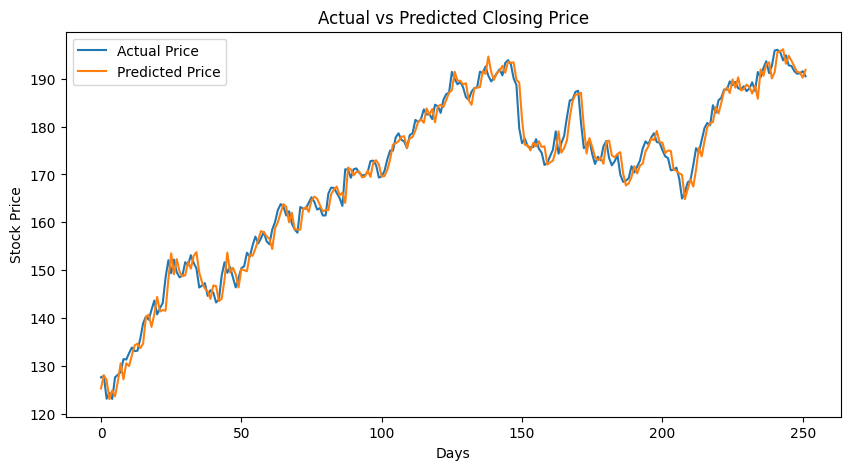

In [8]:
plt.figure(figsize=(10,5))

plt.plot(y_test.values, label="Actual Price")
plt.plot(predictions, label="Predicted Price")

plt.title("Actual vs Predicted Closing Price")
plt.xlabel("Days")
plt.ylabel("Stock Price")
plt.legend()

plt.show()


This graph helps compare:

Real prices

Predicted prices

**TASK 2 COMPLETED**